In [27]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean" / "generalization"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "generalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.fogas_clean import FOGASEvaluator, FOGASHyperOptimizer
from rl_methods.fogas_generalization_clean import *
from rl_methods.sbeed import (
    DiscreteSBEED,
    DiscreteSBEEDDataset,
    LinearValueParam,
    LinearRhoParam,
    SoftmaxLinearPolicyParam,
    TabularStateFeatures,
    TabularStateActionFeatures,
)
from rl_methods.data_collection_clean import DiscreteDataBuffer
from rl_methods.sbeed import SBEEDEvaluator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 3grid empty

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path = DATASETS_DIR / "3grid.csv"
goal_grid = 8


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full(
    (N * A,),
    -0.1,
    dtype=torch.float64,
    device=DEVICE,
)
omega[goal_grid * A : goal_grid * A + A] = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


def psi(xp):
    v = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    for x in states:
        for a in actions:
            if next_state(x, a) == int(xp):
                v[int(x) * A + int(a)] = 1.0
    return v


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
    terminal_states=[goal_grid],
).to(DEVICE)

planner = Planner(mdp)

In [3]:
# Load your fixed offline dataset.
df = pd.read_csv(dataset_path)

done = df["next_state"].astype(int).eq(goal_grid).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.01,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=1,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(2000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=[f"a{a}" for a in range(A)],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = pi_sbeed.argmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0     -0.000000      0.007202      0.007202
 100      0.003354      0.004060      0.000706
 200      0.000674      0.005610      0.004936
 300      0.001633      0.008262      0.006628
 400      0.003853      0.006515      0.002662
 500      0.002480      0.005138      0.002659
 600      0.004051      0.004568      0.000516
 700      0.003475      0.003763      0.000288
 800      0.003512      0.003700      0.000188
 900      0.003511      0.003559      0.000048
1000      0.003394      0.003445      0.000051
1100      0.003376      0.003385      0.000009
1200      0.003279      0.003293      0.000014
1300      0.003214      0.003218      0.000004
1400      0.003122      0.003125      0.000003
1500      0.003037      0.003039      0.000002
1600      0.002946      0.002947      0.000002
1700      0.002866      0.002867      0.000001
1800      0.002787      0.002789      0.000002
1900  

# 3grid walls

In [4]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path_3walls = str(DATASETS_DIR / "3grid_wall.csv")

goal = 8
pit = 5
wall = 4

step_cost = -0.1
goal_reward = 1.0
pit_reward = -1.0


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full((N * A,), step_cost, dtype=torch.float64)
omega[goal * A : goal * A + A] = goal_reward
omega[pit * A : pit * A + A] = pit_reward


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(2, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    sp = to_s(r2, c2)

    if sp == wall:
        return s

    return sp


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal, pit],
)

planner = Planner(mdp, mode="deterministic")

In [5]:
# Load your fixed offline dataset.
df = pd.read_csv(dataset_path_3walls)

done = df["next_state"].astype(int).eq(goal_grid).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.01,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=1,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(2000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=[f"a{a}" for a in range(A)],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = pi_sbeed.argmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0     -0.000000      0.007190      0.007190
 100      0.002873      0.003571      0.000698
 200      0.000989      0.005119      0.004129
 300     -0.000447      0.006244      0.006691
 400      0.003541      0.005572      0.002032
 500      0.001883      0.003841      0.001959
 600      0.002805      0.003058      0.000253
 700      0.002172      0.002612      0.000440
 800      0.002532      0.002649      0.000117
 900      0.002375      0.002400      0.000025
1000      0.002309      0.002350      0.000041
1100      0.002283      0.002306      0.000023
1200      0.002249      0.002259      0.000010
1300      0.002207      0.002213      0.000006
1400      0.002169      0.002181      0.000011
1500      0.002147      0.002149      0.000003
1600      0.002106      0.002110      0.000005
1700      0.002072      0.002077      0.000004
1800      0.002034      0.002036      0.000002
1900  

# 5grid

In [6]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.99
x_0 = 0

dataset_path_5grid = str(DATASETS_DIR / "5grid.csv")

grid_size = 5
goal_grid = 24

wall_states = {6, 7, 12}
terminal_states = {goal_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def next_state(s, a):
    return move_deterministic(s, a)


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


def reward_fn(s, a):
    sp = next_state(s, a)

    if sp == goal_grid:
        return 1.0

    return -0.01


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

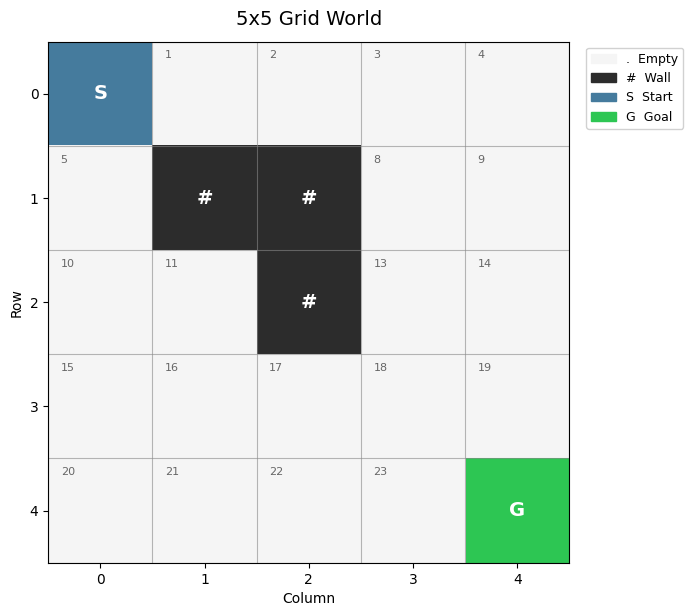

In [7]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

In [ ]:
df = pd.read_csv(dataset_path_5grid)

done = df["next_state"].astype(int).isin(terminal_states).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.0001,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=1e-1,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=5,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(1000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=[f"a{a}" for a in range(A)],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = pi_sbeed.argmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Collected 8000 uniform transitions.
step    objective      primal_mse      dual_mse
----------------------------------------------------
   0      0.067629      0.398579      0.330950
 100      0.021844      0.031631      0.009787
 200     -0.012900      0.004497      0.017397
 300     -0.014359      0.005108      0.019467
 400     -0.014436      0.005398      0.019834
 500     -0.014493      0.005394      0.019887
 600     -0.014558      0.005336      0.019895
 700     -0.014628      0.005268      0.019897
 800     -0.014693      0.005206      0.019899
 900     -0.014752      0.005148      0.019900

Learned SBEED policy
----------------------------------------------------
 state    a0    a1    a2    a3  best
     0 0.285 0.406 0.166 0.143     1
     1 0.009 0.000 0.883 0.108     2
     2 0.000 0.000 0.000 1.000     3
     3 0.000 1.000 0.000 0.000     1
     4 0.000 1.000 0.000 0.000     1
     5 0.000 0.577 0.250 0.173     1
     6 0.250 0.250 0.250 0.250     0
     7 0.250 0.250 0.2

# 5 stochastic grid

In [16]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path_5grid_stoch = str(DATASETS_DIR / "5grid_stochastic.csv")

grid_size = 5
goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a, intended_prob=0.8):
    """
    Stochastic transition:
    intended_prob goes to the requested action.
    The remaining probability is uniform over all actions.
    
    With intended_prob=0.8 and A=4:
      intended action: 0.8 + 0.2 / 4 = 0.85
      other actions:   0.2 / 4 = 0.05 each
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        prob = (1.0 - intended_prob) / A
        if candidate_a == a:
            prob += intended_prob

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return probs_by_state


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)

    for sp, prob in transition_probs(s, a).items():
        probs[sp] = prob

    return probs


def next_state(s, a):
    """
    Sample one next state from the stochastic transition.
    Useful for manual rollouts, not used by DiscreteMDP planning.
    """
    probs = transition_fn(s, a)
    return int(torch.multinomial(probs.float(), num_samples=1).item())


def reward_from_next_state(sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1


def reward_fn(s, a):
    """
    Expected one-step reward under P(. | s, a).
    """
    return sum(
        prob * reward_from_next_state(sp)
        for sp, prob in transition_probs(s, a).items()
    )


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

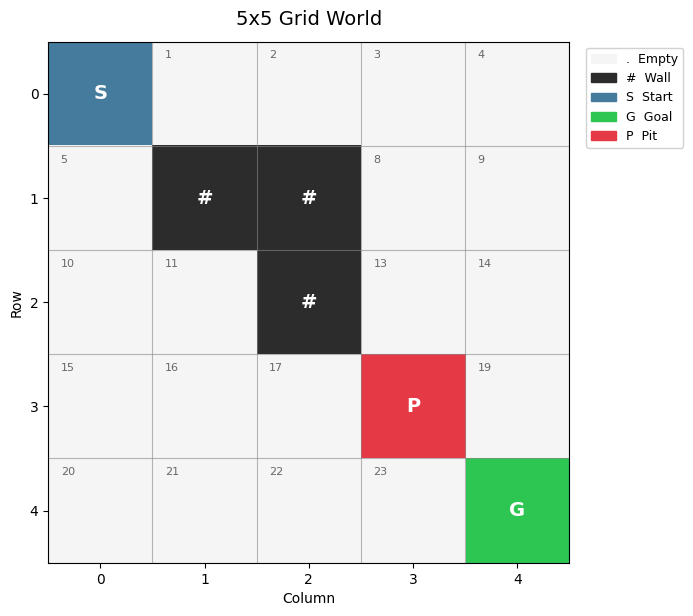

In [17]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(pit_grid)
    grid_data[r, c] = "P"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3, "P": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal", 4: "Pit"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653", "#E63946"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == pit_grid:
            ax.text(c, r, "P", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

In [22]:
df = pd.read_csv(dataset_path_5grid_stoch)

done = df["next_state"].astype(int).isin(terminal_states).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.01,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=3e-2,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=3,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(1000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=[f"a{a}" for a in range(A)],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = pi_sbeed.argmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0      0.012124      0.260142      0.248019
 100      0.039960      0.043574      0.003614
 200      0.019215      0.024157      0.004942
 300      0.012613      0.018299      0.005687
 400      0.008903      0.014968      0.006065
 500      0.005698      0.011940      0.006243
 600      0.003328      0.009745      0.006416
 700      0.001558      0.008151      0.006593
 800      0.000304      0.007049      0.006744
 900     -0.000584      0.006284      0.006868

Learned SBEED policy
----------------------------------------------------
 state    a0    a1    a2    a3  best
     0 0.312 0.333 0.287 0.068     1
     1 0.160 0.210 0.467 0.163     2
     2 0.183 0.174 0.526 0.117     2
     3 0.295 0.074 0.285 0.345     3
     4 0.382 0.287 0.137 0.194     0
     5 0.026 0.671 0.199 0.103     1
     6 0.250 0.250 0.250 0.250     0
     7 0.250 0.250 0.250 0.250     0
     8 0.243 0.000 0.

# 10 grid

In [23]:
states = torch.arange(100, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path_10grid = str(DATASETS_DIR / "10grid_tabular.csv")
dataset_path_10grid_prueba = str(DATASETS_DIR / "10grid_tabular_prueba.csv")

grid_size = 10
goal_grid = 99

pit_grids = {18, 32, 57, 61, 75}

wall_states = {
    4, 11, 14, 17, 21, 22, 27, 34, 37,
    40, 42, 43, 44, 45, 46, 47, 49,
    54, 62, 64, 66, 72, 76, 82, 84, 86, 87, 94
}

terminal_states = {goal_grid, *pit_grids}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a, intended_prob=0.8):
    probs_by_state = {}

    for candidate_a in range(A):
        prob = (1.0 - intended_prob) / A

        if candidate_a == int(a):
            prob += intended_prob

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return probs_by_state


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)

    for sp, prob in transition_probs(s, a).items():
        probs[sp] = prob

    return probs


def next_state(s, a):
    """
    Sample one next state from the stochastic transition.
    Useful for manual rollouts, not used by DiscreteMDP planning.
    """
    probs = transition_fn(s, a)
    return int(torch.multinomial(probs.float(), num_samples=1).item())


def reward_from_next_state(sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp in pit_grids:
        return -5.0

    return -0.1


def reward_fn(s, a):
    """
    Expected one-step reward under P(. | s, a).
    """
    if int(s) in terminal_states:
        return 0.0

    return sum(
        prob * reward_from_next_state(sp)
        for sp, prob in transition_probs(s, a).items()
    )


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

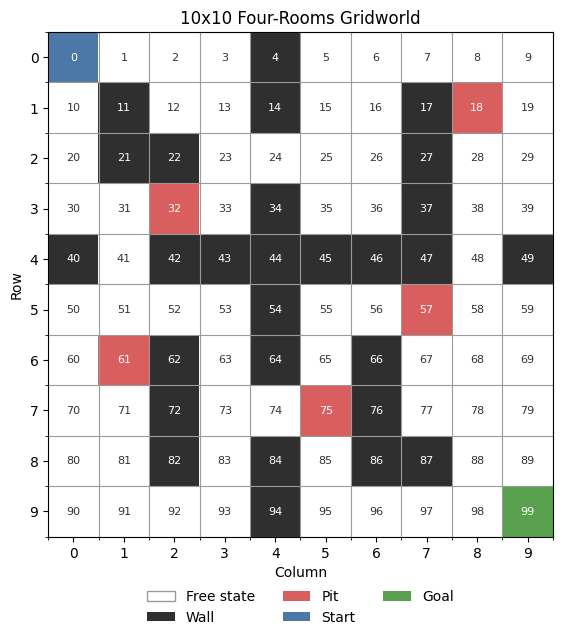

In [24]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

def plot_four_rooms_grid(
    grid_size=10,
    start=0,
    goal=99,
    pits=None,
    walls=None,
    centers=None,
    show_state_ids=True,
    figsize=(6.5, 6.5),
    save_path=None,
):
    pits = set(pits or [])
    walls = set(walls or [])

    # Codes:
    # 0 = free, 1 = wall, 2 = pit, 3 = start, 4 = goal
    grid = np.zeros((grid_size, grid_size), dtype=int)

    for s in walls:
        r, c = divmod(int(s), grid_size)
        grid[r, c] = 1

    for s in pits:
        r, c = divmod(int(s), grid_size)
        grid[r, c] = 2

    sr, sc = divmod(int(start), grid_size)
    gr, gc = divmod(int(goal), grid_size)
    grid[sr, sc] = 3
    grid[gr, gc] = 4

    cmap = ListedColormap([
        "#ffffff",  # free
        "#2f2f2f",  # wall
        "#d95f5f",  # pit
        "#4c78a8",  # start
        "#59a14f",  # goal
    ])
    norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid, cmap=cmap, norm=norm)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#9a9a9a", linewidth=0.8)

    # Axis ticks
    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")

    # Put row 0 at the top, matching divmod indexing
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)

    if show_state_ids:
        for s in range(grid_size * grid_size):
            r, c = divmod(s, grid_size)

            if s in walls:
                color = "white"
            elif s in pits or s == start or s == goal:
                color = "white"
            else:
                color = "#333333"

            ax.text(
                c,
                r,
                str(s),
                ha="center",
                va="center",
                fontsize=8,
                color=color,
            )

    # Optional: plot k-means/RBF centers if passed in normalized coordinates
    if centers is not None:
        centers_np = centers.detach().cpu().numpy() if hasattr(centers, "detach") else np.asarray(centers)

        # Your centers are [row_normalized, col_normalized]
        rows = centers_np[:, 0] * (grid_size - 1)
        cols = centers_np[:, 1] * (grid_size - 1)

        ax.scatter(
            cols,
            rows,
            s=45,
            marker="x",
            linewidths=1.8,
            color="#f28e2b",
            label="RBF centers",
            zorder=5,
        )

    legend_items = [
        Patch(facecolor="#ffffff", edgecolor="#9a9a9a", label="Free state"),
        Patch(facecolor="#2f2f2f", label="Wall"),
        Patch(facecolor="#d95f5f", label="Pit"),
        Patch(facecolor="#4c78a8", label="Start"),
        Patch(facecolor="#59a14f", label="Goal"),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
    )

    ax.set_title("10x10 Four-Rooms Gridworld")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

fig, ax = plot_four_rooms_grid(
    grid_size=10,
    start=0,
    goal=99,
    pits=pit_grids,
    walls=wall_states,
)

plt.show()

In [30]:
collector = DiscreteDataBuffer(
    mdp=mdp,
    restricted_states=wall_states,
    terminal_states={goal_grid},
    seed=SEED,
)

df = collector.collect_uniform(
    samples_per_pair=20,  # 25 states * 4 actions * 80 = 8000 rows
    save_path=str(dataset_path_10grid_prueba),
    verbose=True,
)

df.head()

Collected 8000 uniform transitions.
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/generalization/10grid_tabular_prueba.csv


,episode,step,state,action,reward,next_state
0,0,0,0,0,-0.1,0
1,1,0,0,0,-0.1,0
2,2,0,0,0,-0.1,0
3,3,0,0,0,-0.1,0
4,4,0,0,0,-0.1,0


In [31]:
df = pd.read_csv(dataset_path_10grid_prueba)

done = df["next_state"].astype(int).isin(terminal_states).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),

    lambda_entropy=0.003,
    eta=1.0,

    lr_value=5e-3,
    lr_rho=5e-3,
    lr_policy=3e-3,

    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=1,

    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(3000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

goal_state = 99
terminal_states_eval = {99}

evaluator_sbeed = SBEEDEvaluator(
    solver=solver_sbeed,
    mdp=mdp,
    terminal_states=terminal_states_eval,
)

# One greedy rollout, same idea as FOGAS print_optimal_path
rollout = evaluator_sbeed.simulate_trajectory(
    max_steps=50,
    start_state=x_0,
    seed=SEED,
    greedy=True,
    discounted=True,
)

trajectory = rollout["trajectory"]
reached_goal = any(step["next_state"] == goal_state for step in trajectory)
final_state = trajectory[-1]["next_state"] if trajectory else x_0

print("\nSBEED greedy simulation")
print("-" * 52)

for step in trajectory:
    reached = " GOAL REACHED" if step["next_state"] == goal_state else ""
    print(
        f"Step {step['step']:3d} | "
        f"State: {step['state']:3d} | "
        f"Action: {step['action']:3d} | "
        f"Reward: {step['reward']:8.3f} | "
        f"-> {step['next_state']:3d}{reached}"
    )

print("-" * 52)
print(f"Reached goal: {reached_goal}")
print(f"Trajectory length: {len(trajectory)}")
print(f"Final state: {final_state}")
print(f"Discounted return: {rollout['total_reward']:.6f}")

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0      0.000013      0.933283      0.933270
 100      0.003511      0.765602      0.762091
 200      0.007823      0.652029      0.644206
 300      0.012337      0.569522      0.557186
 400      0.017173      0.507792      0.490619
 500      0.022185      0.460249      0.438064
 600      0.027214      0.423053      0.395839
 700      0.032159      0.393537      0.361378
 800      0.036960      0.369882      0.332921
 900      0.041585      0.350757      0.309172
1000      0.046018      0.335199      0.289181
1100      0.050252      0.322487      0.272235
1200      0.054289      0.312075      0.257786
1300      0.058132      0.303537      0.245405
1400      0.061788      0.296542      0.234754
1500      0.065265      0.290827      0.225562
1600      0.068571      0.286179      0.217608
1700      0.071714      0.282427      0.210713


KeyboardInterrupt: 